In [196]:
setwd("/home/mjehangir/telomere-sv-analysis/data/")


In [197]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(tibble)
library(ggridges)
library(tidyverse)


In [198]:
# RTL matrix (assumes tab-delimited, sample IDs as rownames)
telomeres_MAD <- read.table("telomeres_MAD.txt",
                           sep = "\t",
                           header = TRUE,
                           check.names = FALSE)

# CNV + telomere data file (space-delimited or tab-delimited with uneven spacing)
sv <- read.table("/scratch/mjehangir/manuscript_figures/manuscript_data/severus_somatic_sv_summary_rate_prop_pq.tsv", sep = "", header = TRUE, fill = TRUE, stringsAsFactors = FALSE)
cnv <- read.table("cnvs_summary_rate_prop_pq.tsv", sep = "", header = TRUE, fill = TRUE, stringsAsFactors = FALSE)
head(sv)
head(cnv)
head(telomeres_MAD)

,filename,chr,Arm,arm_size,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,region
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,2436A,chr1,p,124048267,DEL,5,0.131346,124.0483,0.040306891,1.058830e-03,chr1p
2,2436A,chr1,p,124048267,DUP,4,0.034060,124.0483,0.032245513,2.745705e-04,chr1p
3,2436A,chr1,p,124048267,INS,2,0.000002,124.0483,0.016122756,1.612276e-08,chr1p
4,2436A,chr1,p,124048267,INV,1,0.000834,124.0483,0.008061378,6.723189e-06,chr1p
5,2436A,chr1,q,124339061,DEL,3,0.061028,124.3391,0.024127575,4.908192e-04,chr1q
6,2436A,chr1,q,124339061,DUP,2,0.027273,124.3391,0.016085050,2.193438e-04,chr1q


,ID,chrom,Arm,Gain_Loss,total_cnv_length,segment_count,Length,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm
,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,2436A,chr1,q,Gain,0.200152,1,124339061,124.33906,0.008042525,0.001609727,chr1q
2,2436A,chr10,q,Loss,17.220193,2,94108943,94.10894,0.021251965,0.182981473,chr10q
3,2436A,chr10,q,Loss,17.220193,2,94108943,94.10894,0.021251965,0.182981473,chr10q
4,2436A,chr15,q,Gain,1.602465,1,82566565,82.56656,0.012111440,0.019408159,chr15q
5,2436A,chr18,q,Loss,0.200356,1,62092914,62.09291,0.016104897,0.003226713,chr18q
6,2436A,chr19,q,Loss,7.012181,1,33914441,33.91444,0.029485964,0.206760919,chr19q


,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,RTL,chr_arm,median_TL,mad_TL,norm_TL
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5221.000,1,p,5.221000,1.0340362,chr1p,5303.000,1180.083,-0.06948662
2,2436A,chr1q,5051.167,1,q,5.051167,1.0004002,chr1q,5303.000,1180.083,-0.21340301
3,3188,chr1p,1642.500,1,p,1.642500,0.3253025,chr1p,2824.125,399.500,-2.95775970
4,3188,chr1q,3086.500,1,q,3.086500,0.6112915,chr1q,2824.125,399.500,0.65675845
5,3988,chr1p,2347.500,1,p,2.347500,0.4649301,chr1p,5689.500,1319.250,-2.53325753
6,3988,chr1q,5083.000,1,q,5.083000,1.0067049,chr1q,5689.500,1319.250,-0.45973091


In [199]:
sv <- sv %>%
  rename(chr_arm = region, Sample_ID = filename)
head(sv)

,Sample_ID,chr,Arm,arm_size,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,chr_arm
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,2436A,chr1,p,124048267,DEL,5,0.131346,124.0483,0.040306891,1.058830e-03,chr1p
2,2436A,chr1,p,124048267,DUP,4,0.034060,124.0483,0.032245513,2.745705e-04,chr1p
3,2436A,chr1,p,124048267,INS,2,0.000002,124.0483,0.016122756,1.612276e-08,chr1p
4,2436A,chr1,p,124048267,INV,1,0.000834,124.0483,0.008061378,6.723189e-06,chr1p
5,2436A,chr1,q,124339061,DEL,3,0.061028,124.3391,0.024127575,4.908192e-04,chr1q
6,2436A,chr1,q,124339061,DUP,2,0.027273,124.3391,0.016085050,2.193438e-04,chr1q


In [200]:
# Full script: per-arm correlations & two heatmaps with significance stars

#── 0. Load packages ───────────────────────────────────────────────────────────
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library(circlize)
library(grid)

#── 1. SV: wide by type ────────────────────────────────────────────────────────
sv_wide <- sv %>%
  mutate(chr_arm = paste0(chr, Arm)) %>%
  select(Sample_ID, chr_arm, type, sv_rate, sv_proportion) %>%
  pivot_wider(
    names_from  = type,
    values_from = c(sv_rate, sv_proportion),
    values_fill = list(sv_rate = 0, sv_proportion = 0)
  ) %>%
  rename_with(~ gsub(" ", "", .x))

#── 2. CNV: recode & aggregate ─────────────────────────────────────────────────
cnv_summarized <- cnv %>%
  mutate(
    chr_arm   = paste0(chrom, Arm),
    rate_Gain = ifelse(Gain_Loss=="Gain", cnv_rate_per_mb, 0),
    rate_Loss = ifelse(Gain_Loss=="Loss", cnv_rate_per_mb, 0),
    prop_Gain = ifelse(Gain_Loss=="Gain", cnv_proportion_per_mb, 0),
    prop_Loss = ifelse(Gain_Loss=="Loss", cnv_proportion_per_mb, 0)
  ) %>%
  group_by(ID, chr_arm) %>%
  summarise(
    cnv_rate_per_mb_Gain       = sum(rate_Gain, na.rm=TRUE),
    cnv_rate_per_mb_Loss       = sum(rate_Loss, na.rm=TRUE),
    cnv_proportion_per_mb_Gain = sum(prop_Gain, na.rm=TRUE),
    cnv_proportion_per_mb_Loss = sum(prop_Loss, na.rm=TRUE),
    .groups = "drop"
  ) %>%
  rename(Sample_ID = ID)

#── 3. Telomeres ───────────────────────────────────────────────────────────────
tel <- telomeres_MAD %>%
  rename(Sample_ID = Sample_prefix) %>%
  select(Sample_ID, chr_arm, final_average_TL_p75_kb, norm_TL)

#── 4. Merge ──────────────────────────────────────────────────────────────────
all_df <- tel %>%
  left_join(sv_wide, by=c("Sample_ID","chr_arm")) %>%
  left_join(cnv_summarized, by=c("Sample_ID","chr_arm"))


In [201]:
head(all_df)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,sv_rate_DEL,sv_rate_DUP,sv_rate_INS,sv_rate_INV,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_INS,sv_proportion_INV,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5.221000,-0.06948662,0.040306891,0.032245513,0.016122756,0.008061378,0.0010588298,2.745705e-04,1.612276e-08,6.723189e-06,NA,NA,NA,NA
2,2436A,chr1q,5.051167,-0.21340301,0.024127575,0.016085050,0.016085050,0.000000000,0.0004908192,2.193438e-04,1.608505e-08,0.000000e+00,0.008042525,0.00000000,0.001609727,0.0000000
3,3188,chr1p,1.642500,-2.95775970,0.024184135,0.000000000,0.016122756,0.000000000,0.0000386140,0.000000e+00,1.612276e-08,0.000000e+00,0.000000000,0.03224551,0.000000000,0.7357528
4,3188,chr1q,3.086500,0.65675845,0.032170100,0.008042525,0.008042525,0.000000000,0.0004511937,5.141586e-05,8.042525e-09,0.000000e+00,0.008042525,0.00000000,0.008048565,0.0000000
5,3988,chr1p,2.347500,-2.53325753,0.072552404,0.000000000,0.024184135,0.008061378,0.0004531865,0.000000e+00,2.418413e-08,6.723189e-06,NA,NA,NA,NA
6,3988,chr1q,5.083000,-0.45973091,0.008042525,0.008042525,0.016085050,0.008042525,0.0002589854,5.141586e-05,1.608505e-08,9.618860e-06,NA,NA,NA,NA


In [214]:
library(dplyr)

# Strategy 3: MAD-based outlier approach
all_df <- all_df %>%
  group_by(chr_arm) %>%
#group_by(Sample_ID) %>%
  mutate(
    # Step 1: compute the median TL per chromosome arm
    #median_TL = median(final_average_TL_p75_kb, na.rm = TRUE),
    median_TL = median(final_average_TL_p75_kb, na.rm = TRUE),
    # Step 2: compute MAD per arm (robust spread)
    mad_TL = mad(norm_TL, constant = 1, na.rm = TRUE),

    # Step 3: compute robust z-score (scaled MAD ~ comparable to SD)
    #robust_z = ifelse(mad_TL == 0, 0,
     #                 (final_average_TL_p75_kb - median_TL) / (mad_TL * 1.4826)),


      robust_z = ifelse(mad_TL == 0, 0,
                      (norm_TL - median_TL) / (mad_TL * 1.4826)),

    # Step 4: classify into groups
    TL_group = case_when(
      robust_z <= 0 ~ "short",
      robust_z >=  1 ~ "long",
      TRUE ~ "intermediate"
    )
  ) %>%
  ungroup()


In [215]:
head(all_df)

Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,sv_rate_DEL,sv_rate_DUP,sv_rate_INS,sv_rate_INV,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_INS,sv_proportion_INV,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,median_TL,mad_TL,robust_z,TL_group
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2436A,chr1p,5.221000,-0.06948662,0.040306891,0.032245513,0.016122756,0.008061378,0.0010588298,2.745705e-04,1.612276e-08,6.723189e-06,NA,NA,NA,NA,4.28800,0.8664419,-3.392131,short
2436A,chr1q,5.051167,-0.21340301,0.024127575,0.016085050,0.016085050,0.000000000,0.0004908192,2.193438e-04,1.608505e-08,0.000000e+00,0.008042525,0.00000000,0.001609727,0.0000000,4.70475,0.8701615,-3.812222,short
3188,chr1p,1.642500,-2.95775970,0.024184135,0.000000000,0.016122756,0.000000000,0.0000386140,0.000000e+00,1.612276e-08,0.000000e+00,0.000000000,0.03224551,0.000000000,0.7357528,4.28800,0.8664419,-5.640537,short
3188,chr1q,3.086500,0.65675845,0.032170100,0.008042525,0.008042525,0.000000000,0.0004511937,5.141586e-05,8.042525e-09,0.000000e+00,0.008042525,0.00000000,0.008048565,0.0000000,4.70475,0.8701615,-3.137731,short
3988,chr1p,2.347500,-2.53325753,0.072552404,0.000000000,0.024184135,0.008061378,0.0004531865,0.000000e+00,2.418413e-08,6.723189e-06,NA,NA,NA,NA,4.28800,0.8664419,-5.310079,short
3988,chr1q,5.083000,-0.45973091,0.008042525,0.008042525,0.016085050,0.008042525,0.0002589854,5.141586e-05,1.608505e-08,9.618860e-06,NA,NA,NA,NA,4.70475,0.8701615,-4.003159,short


In [216]:
all_df %>% filter(TL_group == "intermediate") %>% nrow()

[1] 9

In [217]:
nrow(all_df)

[1] 831

`geom_smooth()` using formula = 'y ~ x'


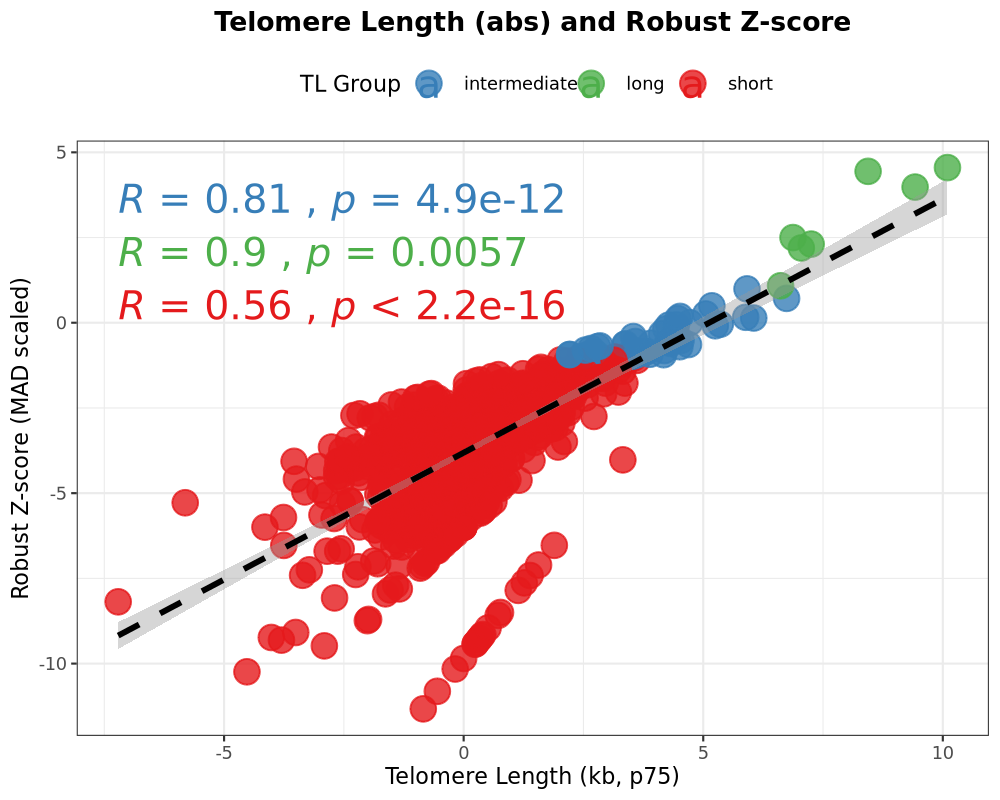

In [212]:
library(ggplot2)
library(ggpubr)

# Scatterplot of TL vs robust_z
p <- ggplot(all_df, aes(#x = final_average_TL_p75_kb,
                        x = norm_TL,
                        y = robust_z, 
                        color = TL_group)) +
  geom_point(size = 4, alpha = 0.8) +
  geom_smooth(method = "lm", se = TRUE, color = "black", linetype = "dashed") +
  stat_cor(method = "pearson", 
           aes(label = paste(..r.label.., ..p.label.., sep = "~`,`~")), 
           label.x.npc = "left", 
           label.y.npc = "top", 
           size = 5) +
  scale_color_manual(values = c("short" = "#E41A1C", 
                                "intermediate" = "#377EB8", 
                                "long" = "#4DAF4A")) +
  labs(
    x = "Telomere Length (kb, p75)",
    y = "Robust Z-score (MAD scaled)",
    color = "TL Group",
    title = "Telomere Length (abs) and Robust Z-score"
  ) +
  theme_bw(base_size = 8) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "top"
  )

options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

# Print plot
print(p)


In [213]:
library(dplyr)
library(ComplexHeatmap)
library(circlize)
library(grid)

#── Features ───────────────────────────
features <- grep("^(sv_rate|sv_proportion|cnv_rate_per_mb|cnv_proportion_per_mb)_",
                 names(all_df), value=TRUE)

#── helper for star annotation ─────────
star <- function(p) {
  if (is.na(p)) return("")
  else if (p < 0.001) return("***")
  else if (p < 0.01)  return("**")
  else if (p < 0.05)  return("*")
  else return("")
}

#── function to compute correlation & p matrices for a given TL group ─────────
compute_corr_mats <- function(df, features) {
  arms <- sort(unique(df$chr_arm))
  corr_mat <- matrix(NA, nrow=length(features), ncol=length(arms),
                     dimnames=list(features, arms))
  p_mat    <- corr_mat
  
  for (a in arms) {
    sub <- filter(df, chr_arm==a)
    for (f in features) {
      x <- sub[[f]]
      y <- sub$final_average_TL_p75_kb
      ok <- complete.cases(x,y)
      if (sum(ok) >= 3) {
        t <- cor.test(x[ok], y[ok], method="pearson")
        corr_mat[f,a] <- t$estimate
        p_mat[f,a]    <- t$p.value
      }
    }
  }
  list(corr=corr_mat, p=p_mat)
}

#── split dataset by TL_group ──────────
df_short        <- filter(all_df, TL_group=="short")
df_intermediate <- filter(all_df, TL_group=="intermediate")
df_long         <- filter(all_df, TL_group=="long")

#── compute correlation matrices ───────
res_short        <- compute_corr_mats(df_short, features)
res_intermediate <- compute_corr_mats(df_intermediate, features)
res_long         <- compute_corr_mats(df_long, features)

#── make Heatmap objects ───────────────
make_heatmap <- function(corr_mat, p_mat, title) {
  Heatmap(
    corr_mat,
    name = "Pearson r",
    col = colorRamp2(c(-1, 0, 1), c("blue", "white", "red")),
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    column_title = title,
    row_title = "Feature",
    cell_fun = function(j, i, x, y, w, h, fill) {
      grid.rect(x = x, y = y, width = w, height = h,
                gp = gpar(col = "black", lwd = 0.5, fill = NA))
      s <- star(p_mat[i, j])
      if (nzchar(s)) {
        grid.text(s, x = x, y = y,
                  gp = gpar(fontsize = 14, col = "white", fontface = "bold"))
      }
    },
    heatmap_legend_param = list(title = "Pearson r")
  )
}

#── create three heatmaps ──────────────
ht1_short        <- make_heatmap(res_short$corr,        res_short$p,        "Short TL Group")
ht1_intermediate <- make_heatmap(res_intermediate$corr, res_intermediate$p, "Intermediate TL Group")
ht1_long         <- make_heatmap(res_long$corr,        res_long$p,        "Long TL Group")

Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation is zero”
Warning message in cor(x, y):
“the standard deviation i

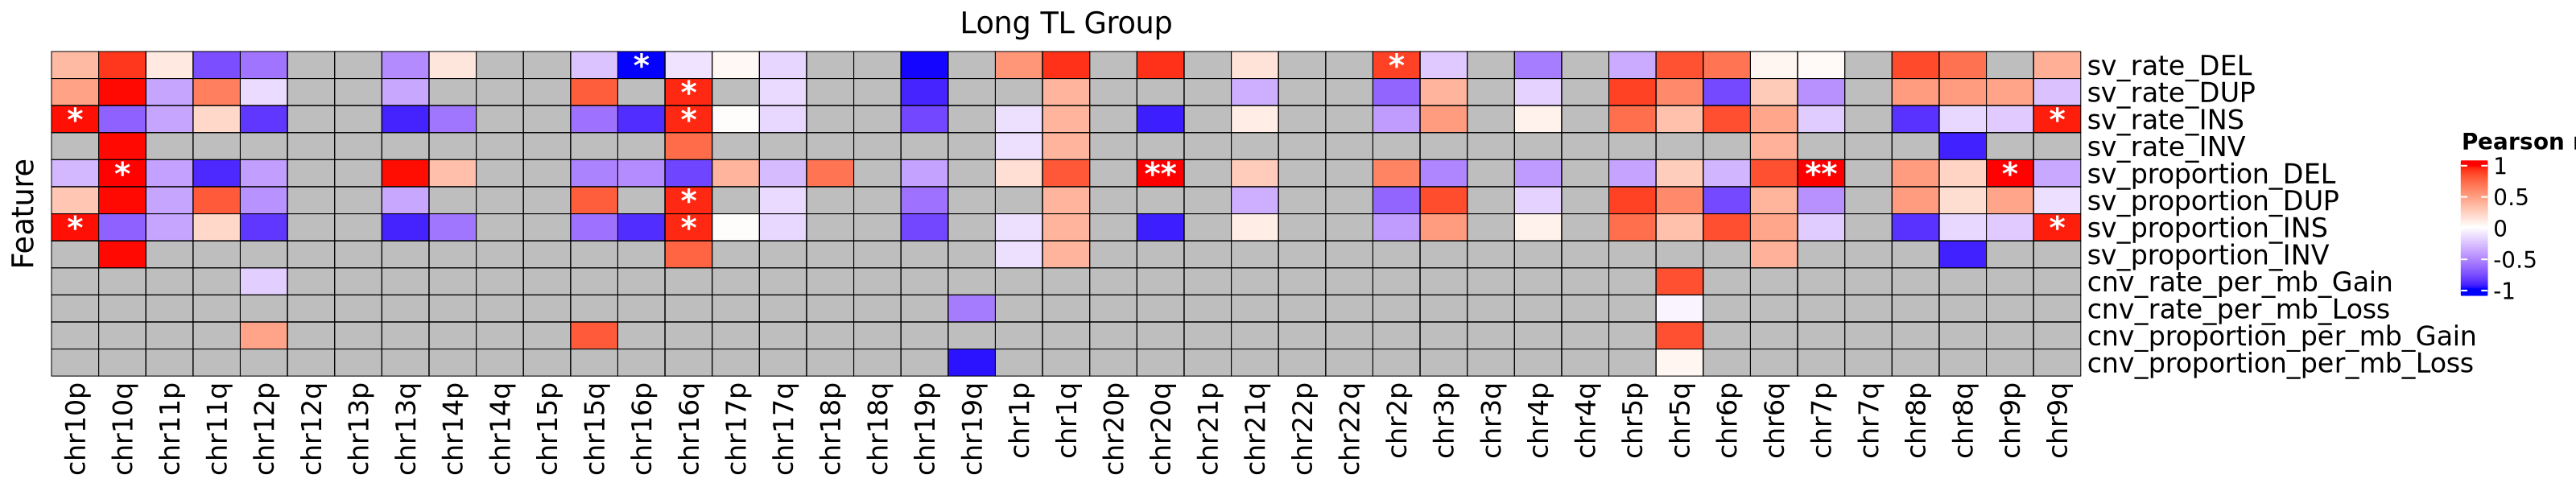

In [188]:
options(repr.plot.width = 16, repr.plot.height = 3, repr.plot.res = 200)

#── draw individually ──────────────────
#draw(ht1_short, heatmap_legend_side="right")
#draw(ht1_intermediate, heatmap_legend_side="right")
draw(ht1_long, heatmap_legend_side="right")

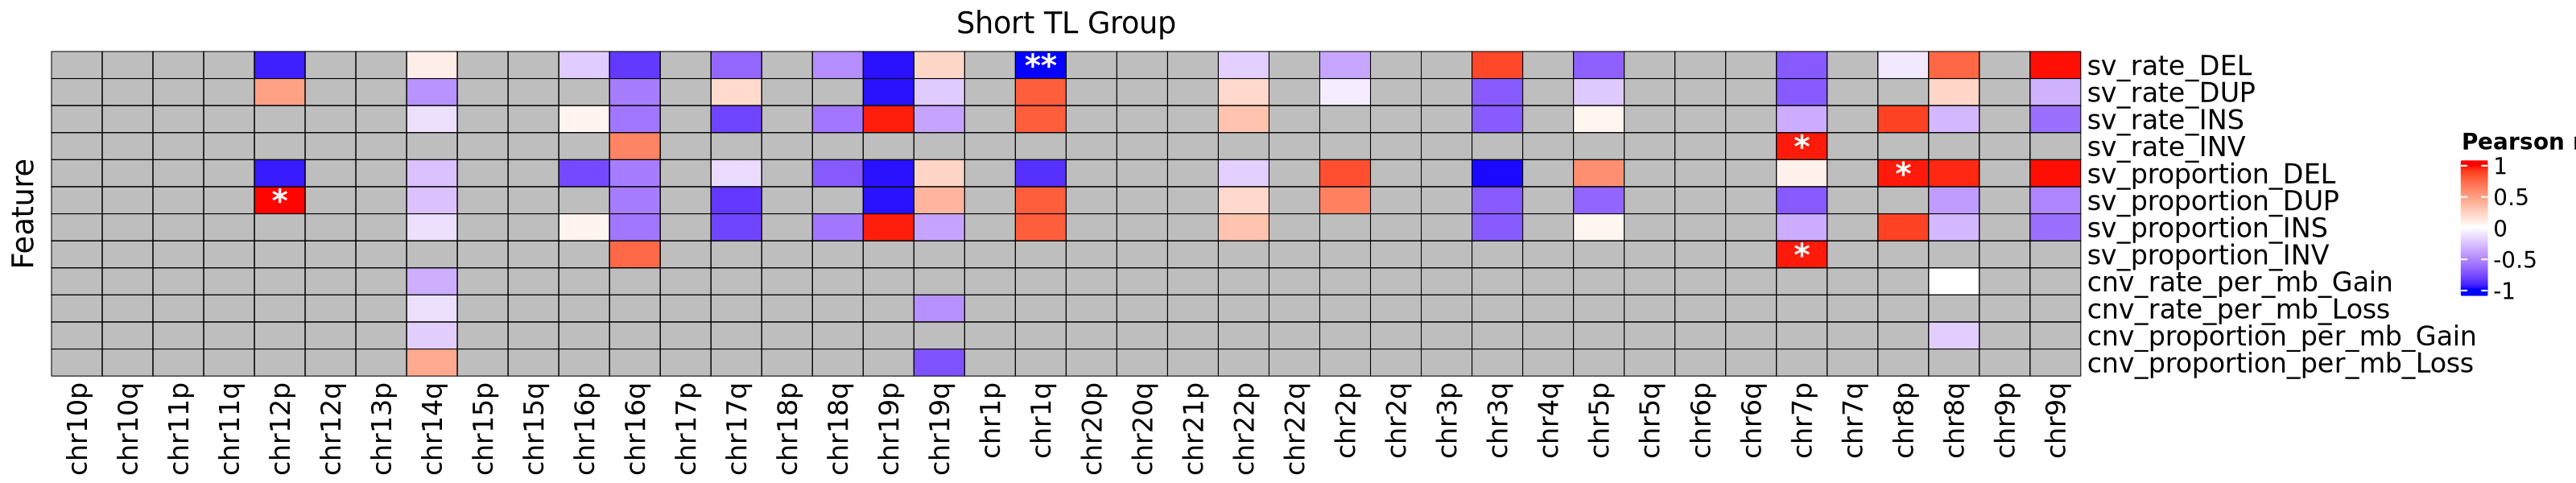

In [194]:
options(repr.plot.width = 16, repr.plot.height = 3, repr.plot.res = 200)

#── draw individually ──────────────────
draw(ht1_short, heatmap_legend_side="right")

In [189]:
head(all_df)

Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,sv_rate_DEL,sv_rate_DUP,sv_rate_INS,sv_rate_INV,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_INS,sv_proportion_INV,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,median_TL,mad_TL,robust_z,TL_group
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2436A,chr1p,5.221000,-0.06948662,0.040306891,0.032245513,0.016122756,0.008061378,0.0010588298,2.745705e-04,1.612276e-08,6.723189e-06,NA,NA,NA,NA,4.28800,0.97800,0.6434559,intermediate
2436A,chr1q,5.051167,-0.21340301,0.024127575,0.016085050,0.016085050,0.000000000,0.0004908192,2.193438e-04,1.608505e-08,0.000000e+00,0.008042525,0.00000000,0.001609727,0.0000000,4.70475,0.80675,0.2896248,intermediate
3188,chr1p,1.642500,-2.95775970,0.024184135,0.000000000,0.016122756,0.000000000,0.0000386140,0.000000e+00,1.612276e-08,0.000000e+00,0.000000000,0.03224551,0.000000000,0.7357528,4.28800,0.97800,-1.8245044,short
3188,chr1q,3.086500,0.65675845,0.032170100,0.008042525,0.008042525,0.000000000,0.0004511937,5.141586e-05,8.042525e-09,0.000000e+00,0.008042525,0.00000000,0.008048565,0.0000000,4.70475,0.80675,-1.3529528,short
3988,chr1p,2.347500,-2.53325753,0.072552404,0.000000000,0.024184135,0.008061378,0.0004531865,0.000000e+00,2.418413e-08,6.723189e-06,NA,NA,NA,NA,4.28800,0.97800,-1.3382917,short
3988,chr1q,5.083000,-0.45973091,0.008042525,0.008042525,0.016085050,0.008042525,0.0002589854,5.141586e-05,1.608505e-08,9.618860e-06,NA,NA,NA,NA,4.70475,0.80675,0.3162394,intermediate


In [190]:
options(repr.plot.width = 8, repr.plot.height = 12, repr.plot.res = 200)


In [191]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(rstatix)

# 1. Select genomic features
features <- grep("^(sv_rate|sv_proportion|cnv_rate_per_mb|cnv_proportion_per_mb)_",
                 names(all_df), value=TRUE)

# 2. Function: compute correlation per feature × chr_arm
compute_group_corr <- function(df, group_name) {
  res <- lapply(features, function(f) {
    lapply(unique(df$chr_arm), function(a) {
      sub <- df %>% filter(chr_arm == a)
      x <- sub[[f]]
      y <- sub$final_average_TL_p75_kb
      ok <- complete.cases(x, y)
      
      if (sum(ok) >= 3 && sd(x[ok]) > 0 && sd(y[ok]) > 0) {
        t <- cor.test(x[ok], y[ok], method="pearson")
        data.frame(Feature=f, Correlation=t$estimate, chr_arm=a)
      } else {
        data.frame(Feature=f, Correlation=NA, chr_arm=a)
      }
    }) %>% bind_rows()
  }) %>% bind_rows()
  res$TL_group <- group_name
  res
}

# 3. Compute correlations for each TL_group
cor_short        <- compute_group_corr(filter(all_df, TL_group=="short"), "short")
cor_intermediate <- compute_group_corr(filter(all_df, TL_group=="intermediate"), "intermediate")
cor_long         <- compute_group_corr(filter(all_df, TL_group=="long"), "long")

# 4. Combine all results
cor_df <- bind_rows(cor_short, cor_intermediate, cor_long) %>%
  filter(!is.na(Correlation))

# 5. Run pairwise Wilcoxon tests per Feature
stat.test <- cor_df %>%
  group_by(Feature) %>%
  pairwise_wilcox_test(
    Correlation ~ TL_group,
    p.adjust.method = "BH"
  ) %>%
  filter(p.adj < 0.05) %>%                # keep only significant
  add_xy_position(x = "TL_group") %>%     # assign y-positions
  ungroup()

In [192]:
head(cor_df)

,Feature,Correlation,chr_arm,TL_group
,<chr>,<dbl>,<chr>,<chr>
cor...1,sv_rate_DEL,-0.9985456,chr1q,short
cor...2,sv_rate_DEL,-0.3844326,chr2p,short
cor...3,sv_rate_DEL,0.8725231,chr3q,short
cor...4,sv_rate_DEL,-0.6835039,chr5p,short
cor...5,sv_rate_DEL,-0.7134207,chr7p,short
cor...6,sv_rate_DEL,-0.0939405,chr8p,short


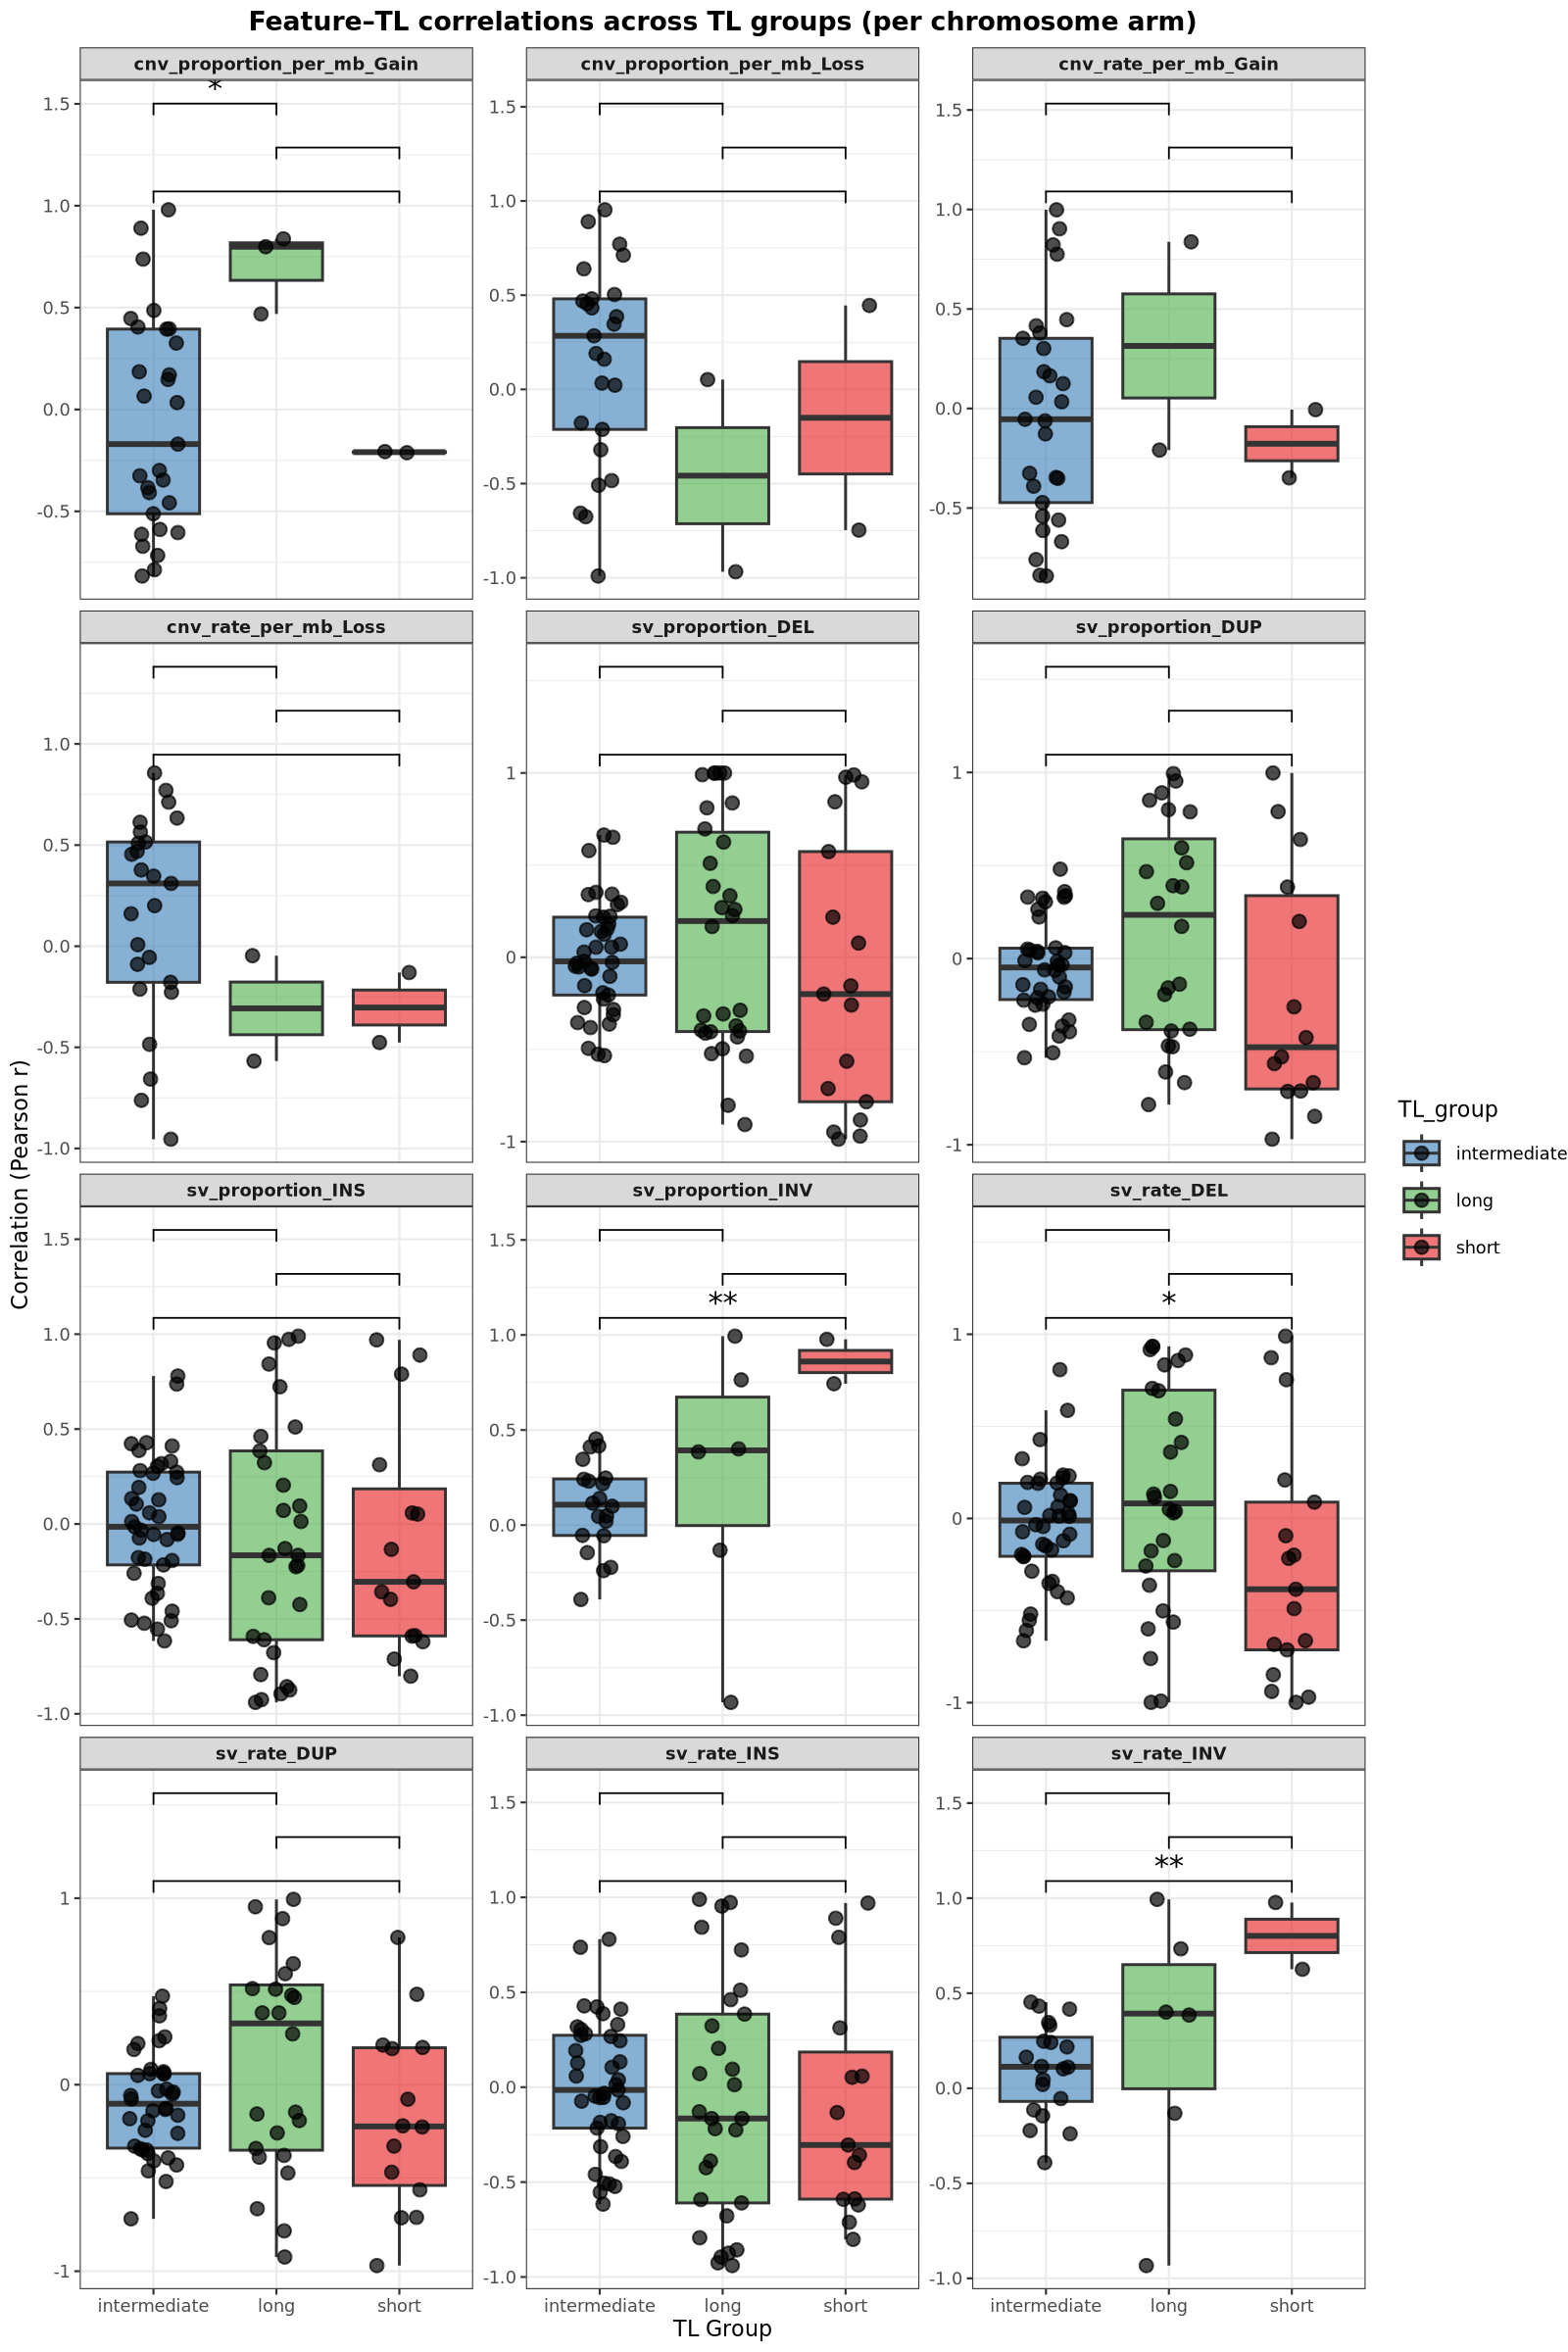

In [193]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)

# 1. Select genomic features
features <- grep("^(sv_rate|sv_proportion|cnv_rate_per_mb|cnv_proportion_per_mb)_",
                 names(all_df), value=TRUE)

# 2. Function: compute correlation per feature × chr_arm
compute_group_corr <- function(df, group_name) {
  res <- lapply(features, function(f) {
    lapply(unique(df$chr_arm), function(a) {
      sub <- df %>% filter(chr_arm == a)
      x <- sub[[f]]
      y <- sub$final_average_TL_p75_kb
      ok <- complete.cases(x, y)
      
      if (sum(ok) >= 3 && sd(x[ok]) > 0 && sd(y[ok]) > 0) {
        t <- cor.test(x[ok], y[ok], method="pearson")
        data.frame(Feature=f, Correlation=t$estimate, chr_arm=a)
      } else {
        data.frame(Feature=f, Correlation=NA, chr_arm=a)
      }
    }) %>% bind_rows()
  }) %>% bind_rows()
  res$TL_group <- group_name
  res
}

# 3. Compute correlations for each TL_group
cor_short        <- compute_group_corr(filter(all_df, TL_group=="short"), "short")
cor_intermediate <- compute_group_corr(filter(all_df, TL_group=="intermediate"), "intermediate")
cor_long         <- compute_group_corr(filter(all_df, TL_group=="long"), "long")

# 4. Combine all results
cor_df <- bind_rows(cor_short, cor_intermediate, cor_long) %>%
  filter(!is.na(Correlation))  # drop NAs

# 5. Plot: Correlation distributions per TL_group
p <- ggplot(cor_df, aes(x = TL_group, y = Correlation, fill = TL_group)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.6) +
  geom_jitter(width = 0.2, size = 2, alpha = 0.7) +
  facet_wrap(~ Feature, scales = "free_y", ncol = 3) +
  stat_compare_means(
    comparisons = list(c("short","intermediate"),
                       c("short","long"),
                       c("intermediate","long")),
    method = "wilcox.test",
    label = "p.signif",
    hide.ns = TRUE   # hides ns labels, but bars remain
  ) +
  scale_fill_manual(values = c("short" = "#E41A1C",
                               "intermediate" = "#377EB8",
                               "long" = "#4DAF4A")) +
  labs(
    x = "TL Group",
    y = "Correlation (Pearson r)",
    title = "Feature–TL correlations across TL groups (per chromosome arm)"
  ) +
  theme_bw(base_size = 8) +
  theme(
    strip.text = element_text(face="bold"),
    plot.title = element_text(hjust = 0.5, face="bold")
  )

print(p)
